In [25]:
import os

os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec

from pathlib import Path
from astropy.io import ascii

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def _make_mag_name(filter):
    return fr'$m_{{\mathrm{{{str(filter)}}}}}$'


In [38]:
stellar_track_cat_dir       = 'Stellar_tracks/track_data/'
stellar_track_cat_path      =  stellar_track_cat_dir +  'STELLAR_MODELS_z=0_04_age_8.dat'
table                       = ascii.read(stellar_track_cat_path)


print(table.keys())


['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'F070Wmag', 'F090Wmag', 'F115Wmag', 'F150Wmag', 'F200Wmag', 'F277Wmag', 'F356Wmag', 'F444Wmag', 'F150W2mag', 'F322W2mag', 'F140Mmag', 'F162Mmag', 'F182Mmag', 'F210Mmag', 'F250Mmag', 'F300Mmag', 'F335Mmag', 'F360Mmag', 'F410Mmag', 'F430Mmag', 'F460Mmag', 'F480Mmag', 'F150WS60mag']


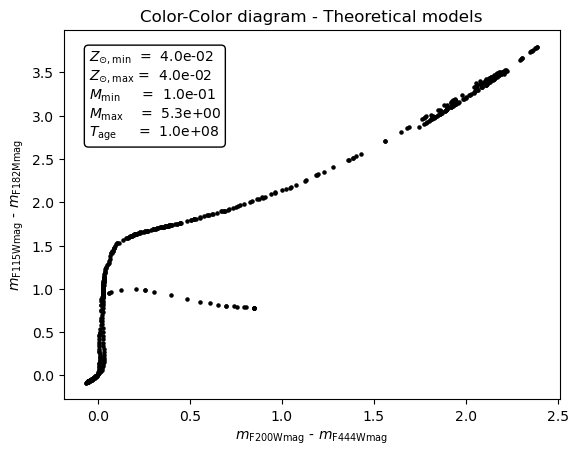

In [ ]:
def plot_CC_diagram(table, filtx1= 'F200Wmag', filtx2='F444Wmag', filty1='F115Wmag', filty2='F182Mmag'):

    fig = plt.figure()
    gs = gridspec.GridSpec(1,1, figure=fig)
    ax  = fig.add_subplot(gs[0,0])

    Fx1_Fx2 = table[filtx1] - table[filtx2] 
    Fy1_Fy2 = table[filty1] - table[filty2] 

    param_text = (
        f"$Z_{{\\odot, \\mathrm{{min}}}}$  = {table['Zini'].min():>8.1e}\n"
        f"$Z_{{\\odot, \\mathrm{{max}}}}$ = {table['Zini'].max():>8.1e}\n"
        f"$M_{{\\mathrm{{min}}}}$     = {table['Mini'].min():>8.1e}\n"
        f"$M_{{\\mathrm{{max}}}}$    = {table['Mini'].max():>8.1e}\n"
        f"$T_{{\\mathrm{{age}}}}$     = {10**table['logAge'].min():>8.1e}"
    )


    ax.text(0.05, 0.95, param_text,transform=ax.transAxes, verticalalignment="top",bbox=dict(boxstyle="round", facecolor="white", alpha=1) )

    ax.scatter(Fx1_Fx2, Fy1_Fy2, color='black', s=5, label='')

    ax.set_xlabel(f'{_make_mag_name(filtx1)} - {_make_mag_name(filtx2)}')
    ax.set_ylabel(f'{_make_mag_name(filty1)} - {_make_mag_name(filty2)}')

    plt.title(f'Color-Color diagram - Theoretical model')
    plt.show()
    return

plot_CC_diagram(table = table)